<a href="https://colab.research.google.com/github/osoria80/05MIAR-Aprendizaje-supervisado/blob/main/ComputerVisionC1/Actividad_Computer_Vision_C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convocatoria 1 - Proyecto 1
Autor: Oscar soria Corral

#### 0) Cargar una de las imágenes histológicas

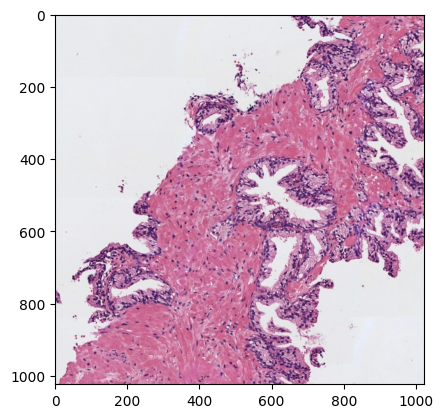

In [2]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
from skimage import io
img = io.imread('histo_1.jpg')
rgb = img.copy()

# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
rgb_p = rgb.astype('uint8')/255

# Visualizar la imagen
import matplotlib.pyplot as plt
plt.imshow(rgb_p)

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

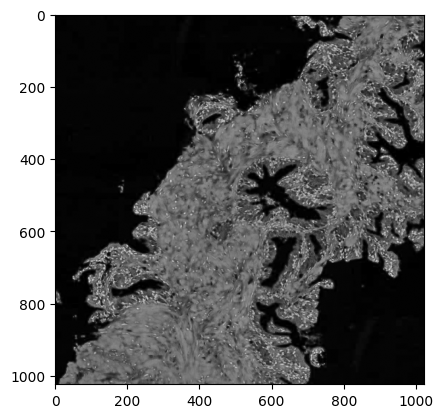

In [3]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
import numpy as np
import cv2
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    C = (1-rgb_p[:,:,0]-K)/(1-K)
    M = (1-rgb_p[:,:,1]-K)/(1-K)
    Y = (1-rgb_p[:,:,2]-K)/(1-K)

CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
C,M,Y,K = cv2.split(CMYK)

# Visualizar la imagen del canal magenta
plt.imshow(M.astype('uint8'), cmap='gray')

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

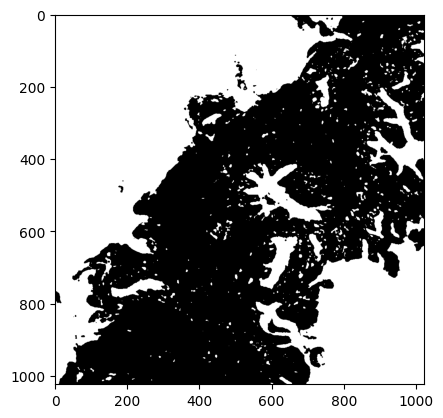

In [4]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
img_gaus = cv2.GaussianBlur(M.astype('uint8'), (5,5), 0)
_, mask = cv2.threshold(img_gaus,0,1,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Visualizar la máscara resultante
plt.imshow(mask, cmap='gray')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

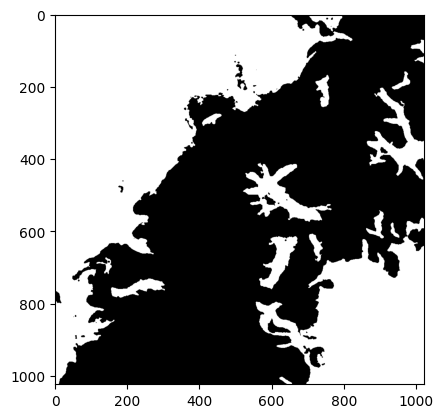

In [5]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
import skimage.morphology as morph
mask_filtered = morph.remove_small_objects(mask.astype(bool), min_size=300)
mask_filtered = mask_filtered.astype('uint8')

# Visualizaer la máscara resultante
plt.imshow(mask_filtered, cmap='gray')
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

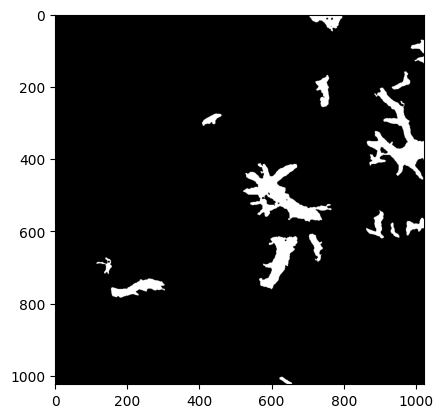

In [6]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
mask_copy = mask_filtered.copy()
h, w = mask_copy.shape
ref = np.zeros((h+2, w+2), np.uint8)
cv2.floodFill(mask_copy, ref, (0,0), 0);
cv2.floodFill(mask_copy, ref, (1000,1000), 0);
# Visualizar la máscara resultante.
plt.imshow(mask_copy, cmap='gray')

#### 5) Rellenar los objetos de los lúmenes

/tmp/ipython-input-218/1071666362.py:3: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  mask_filled = morphology.binary_fill_holes(mask_copy).astype('uint8')


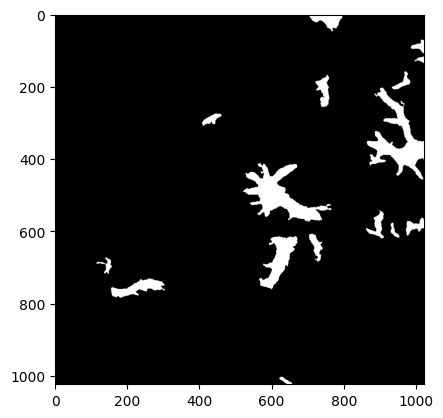

In [7]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
from scipy.ndimage import morphology
mask_filled = morphology.binary_fill_holes(mask_copy).astype('uint8')
# Visualizar la máscara resultante
plt.imshow(mask_filled, cmap='gray')

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

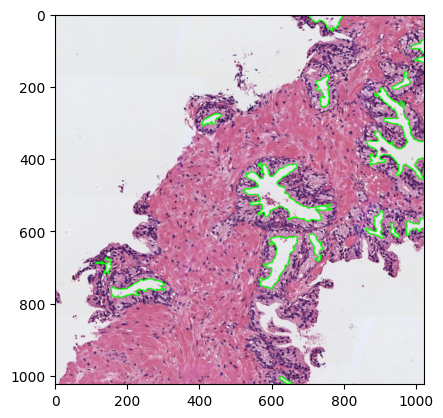

In [8]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles.
contours, _ = cv2.findContours(mask_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Visualizar la imagen superpuesta
rgb_contours = rgb.copy()
cv2.drawContours(rgb_contours, contours, -1, (0,255,0), 2)
plt.imshow(rgb_contours)

#### 7) Identificar y cropear el lumen más grande

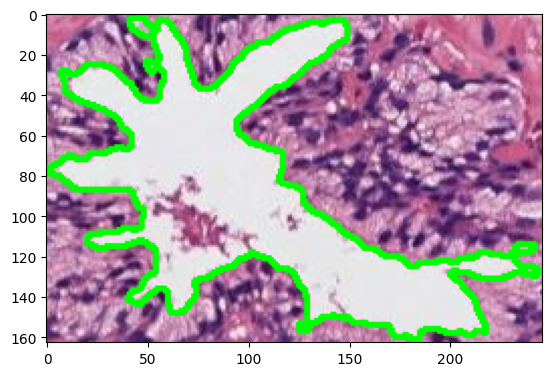

In [15]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
from skimage.measure import label
lab, num = label(mask_filled, return_num=True)
area_max = 0
for i in range(1, num+1):
  objeto = lab==i
  objeto = objeto.astype('uint8')
  area = np.sum(objeto)
  if area > area_max:
    area_max = area
    objeto_max = objeto

prop = regionprops(objeto_max)
bbox = prop[0].bbox
rgb_crop = rgb_contours[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Visualizar el lumen cropeado.
plt.imshow(rgb_crop)


#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado

In [18]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
from skimage.measure import regionprops
import math
from tabulate import tabulate

A,BB,CA,E,ED,EX,DF,MA,MiA,OR,P,S,CO = ['area'], ['bbox_area'], ['convex_area'], ['eccentricity'], ['equiv_diameter'], \
['extent'],['diameter_feret'], ['major_axis'], ['minor_axis'], ['orientation'], ['perimeter'], ['solidity'], ['compactness']

A.append(np.round(prop[0].area, 4))
BB.append(np.round(prop[0].bbox_area, 4))
CA.append(np.round(prop[0].convex_area, 4))
E.append(np.round(prop[0].eccentricity, 4))
ED.append(np.round(prop[0].equivalent_diameter, 4))
EX.append(np.round(prop[0].extent, 4))
DF.append(np.round(prop[0].feret_diameter_max, 4))
MA.append(np.round(prop[0].major_axis_length, 4))
MiA.append(np.round(prop[0].minor_axis_length, 4))
OR.append(np.round(prop[0].orientation, 4))
P.append(np.round(prop[0].perimeter, 4))
S.append(np.round(prop[0].solidity, 4))
CO.append(np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4))

my_data = [A,BB,CA,E,ED,EX,DF,MA,MiA,OR,P,S,CO]
print(tabulate(my_data))


--------------  ----------
area            14110
bbox_area       40098
convex_area     29267
eccentricity        0.847
equiv_diameter    134.035
extent              0.3519
diameter_feret    259.077
major_axis        238.527
minor_axis        126.796
orientation         1.0052
perimeter        1238.32
solidity            0.4821
compactness         0.1156
--------------  ----------
